In [ ]:
# mount gdrive with this code
from google.colab import drive
drive.mount('/content/drive')
#below where the file is in gdrive, change with yours
data_path = "/content/drive/My Drive/Vision_AI_Dataset/"

Mounted at /content/drive


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, concatenate
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.activations import softmax
from tensorflow.keras.losses import categorical_crossentropy

import pandas as pd
import numpy as np

In [ ]:
# load 2 input Xs
df1 = pd.read_csv('VAI_Answer_CLIP_Digits_Img_Vecs.csv')
data1 = df1.values
df2 = pd.read_csv('VAI_Answer_CLIP_Digits_Text_Vecs.csv')
data2 = df2.values

In [ ]:
print(data1.shape, data2.shape)
print(data1.shape[1], data2.shape[1])

(299, 1568) (299, 3072)
1568 3072


In [ ]:
'''

# Example image features tensor
image_features = np.array([[1.0, 2.0, 3.0],
                           [4.0, 5.0, 6.0],
                           [7.0, 8.0, 9.0]])

# Calculate L2 norm along the last dimension
norm = np.linalg.norm(image_features, axis=-1, keepdims=True)

# Normalize image features
image_features_normalized = image_features / norm

print(norm)
print("Original image features:")
print(image_features)
print("\nNormalized image features:")
print(image_features_normalized)
'''

'\n\n# Example image features tensor\nimage_features = np.array([[1.0, 2.0, 3.0],\n                           [4.0, 5.0, 6.0],\n                           [7.0, 8.0, 9.0]])\n\n# Calculate L2 norm along the last dimension\nnorm = np.linalg.norm(image_features, axis=-1, keepdims=True)\n\n# Normalize image features\nimage_features_normalized = image_features / norm\n\nprint(norm)\nprint("Original image features:")\nprint(image_features)\nprint("\nNormalized image features:")\nprint(image_features_normalized)\n'

In [ ]:
Z_VecDim = 300
# Network 1
input1 = Input(shape=(data1.shape[1],))
dense1_net1 = Dense(1000, activation='relu')(input1)
dense2_net1 = Dense(750, activation='relu')(dense1_net1)
dense3_net1 = Dense(500, activation='relu')(dense2_net1)
output_net1 = Dense(Z_VecDim, activation='tanh')(dense3_net1)

# Define model 1
model_net1 = Model(inputs=input1, outputs=output_net1)

# Network 2
input2 = Input(shape=(data2.shape[1],))
dense1_net2 = Dense(2200, activation='relu')(input2)
dense2_net2 = Dense(1600, activation='relu')(dense1_net2)
dense3_net2 = Dense(900, activation='relu')(dense2_net2)
dense4_net2 = Dense(500, activation='relu')(dense3_net2)
output_net2 = Dense(Z_VecDim, activation='tanh')(dense4_net2)

# Define model 2
model_net2 = Model(inputs=input2, outputs=output_net2)

# **Please finish the Contrastive Loss implementation here!!!**

In [ ]:
def compute_loss(image_embeddings, caption_embeddings, temperature):
    """
    .............................
    Compute the contrastive loss between the image and caption embeddings.
    .............................
    """

    # Return the mean of the loss over the batch.
    return (captions_loss + images_loss) / 2


In [ ]:
# Custom training loop..... ***** BUT, NO handle of batch size
learning_rate = 0.0001
epochs = 100
temperature = 0.3

# optimizer_net1 = tf.keras.optimizers.SGD(learning_rate)
# optimizer_net2 = tf.keras.optimizers.SGD(learning_rate)
optimizer_net1 = Adam(learning_rate)
optimizer_net2 = Adam(learning_rate)

for epoch in range(epochs):
    with tf.GradientTape() as tape:
        # Forward pass
        image_embeddings = model_net1(data1)
        caption_embeddings = model_net2(data2)

        # Loss value
        loss = compute_loss(image_embeddings, caption_embeddings, temperature)

    # Get gradients of loss wrt the weights.
    gradients = tape.gradient(loss, [model_net1.trainable_variables, model_net2.trainable_variables])

    gradients_net1 = gradients[0]
    gradients_net2 = gradients[1]

    # Update the weights of the model.
    optimizer_net1.apply_gradients(zip(gradients_net1, model_net1.trainable_variables))
    optimizer_net2.apply_gradients(zip(gradients_net2, model_net2.trainable_variables))

    if epoch % 10 == 0:
      array = loss.numpy()
      print(f'Epoch {epoch}/{epochs}, Loss: {np.mean(array)}')

Epoch 0/100, Loss: 5.703615665435791
Epoch 10/100, Loss: 5.154471397399902
Epoch 20/100, Loss: 4.767569065093994
Epoch 30/100, Loss: 4.708071231842041
Epoch 40/100, Loss: 4.694174289703369
Epoch 50/100, Loss: 4.689420700073242
Epoch 60/100, Loss: 4.687189102172852
Epoch 70/100, Loss: 4.685953617095947
Epoch 80/100, Loss: 4.685184478759766
Epoch 90/100, Loss: 4.6846537590026855


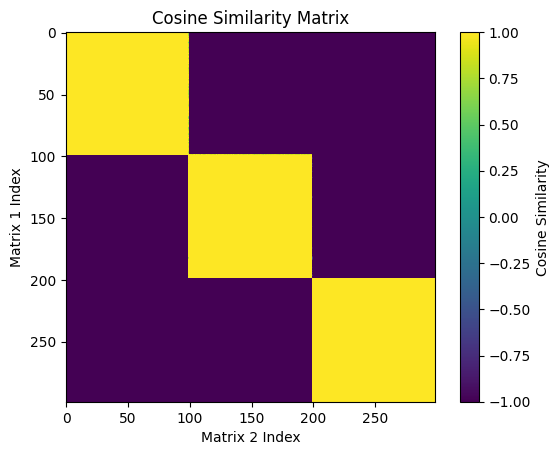

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# from sklearn.metrics.pairwise import cosine_similarity

# Generate two sample matrices
image_embeddings = model_net1(data1)
caption_embeddings = model_net2(data2)

# Compute cosine similarity
# cos_sim_matrix = cosine_similarity(image_embeddings, caption_embeddings)
cos_sim_matrix = tf.matmul(image_embeddings, caption_embeddings, transpose_b=True)

# Visualize the cosine similarity matrix
plt.imshow(cos_sim_matrix, cmap='viridis', vmin=-1, vmax=1)
plt.colorbar(label='Cosine Similarity')
plt.title('Cosine Similarity Matrix')
plt.xlabel('Matrix 2 Index')
plt.ylabel('Matrix 1 Index')
plt.show()